In [ ]:
!pip install -q clickhouse-connect pandas

In [ ]:
import clickhouse_connect
import pandas as pd

client = clickhouse_connect.get_client(
    host="sql-clickhouse.clickhouse.com",
    port=443,
    username="demo",
    secure=True
)

In [ ]:
NUMBER_OF_YEARS = 4

PACKAGES = [
    "logicqubit",
    "logicqubit-gpu",
]

total_query = """
SELECT
    project,
    count() AS total_downloads
FROM pypi.pypi
WHERE
    project IN {packages:Array(String)}
    AND date >= addYears(today(), -{years:UInt8})
    AND date < today()
    AND lower(ifNull(installer, '')) NOT IN (
        '',
        'bandersnatch',
        'z3c.pypimirror',
        'artifactory',
        'devpi'
    )
GROUP BY project
ORDER BY project
"""

total_df = client.query_df(
    total_query,
    parameters={
        "packages": [package.lower() for package in PACKAGES],
        "years": NUMBER_OF_YEARS
    }
)

combined_total = int(total_df["total_downloads"].sum())

display(total_df)

print()
for _, row in total_df.iterrows():
    print(
        f"Total downloads for {row['project']} in the last {NUMBER_OF_YEARS} years:",
        f"{int(row['total_downloads']):,}".replace(",", ".")
    )

print()
print(
    f"Combined total downloads in the last {NUMBER_OF_YEARS} years:",
    f"{combined_total:,}".replace(",", ".")
)

,project,total_downloads
0,logicqubit,8830
1,logicqubit-gpu,14442



Total downloads for logicqubit in the last 4 years: 8.830
Total downloads for logicqubit-gpu in the last 4 years: 14.442

Combined total downloads in the last 4 years: 23.272


,month,downloads,month_label
0,2025-06-01,290,2025-06
1,2025-07-01,459,2025-07
2,2025-08-01,157,2025-08
3,2025-09-01,228,2025-09
4,2025-10-01,263,2025-10
5,2025-11-01,432,2025-11
6,2025-12-01,301,2025-12
7,2026-01-01,297,2026-01
8,2026-02-01,233,2026-02
9,2026-03-01,398,2026-03


Combined total downloads for logicqubit, logicqubit-gpu in the last 12 complete months: 3.459


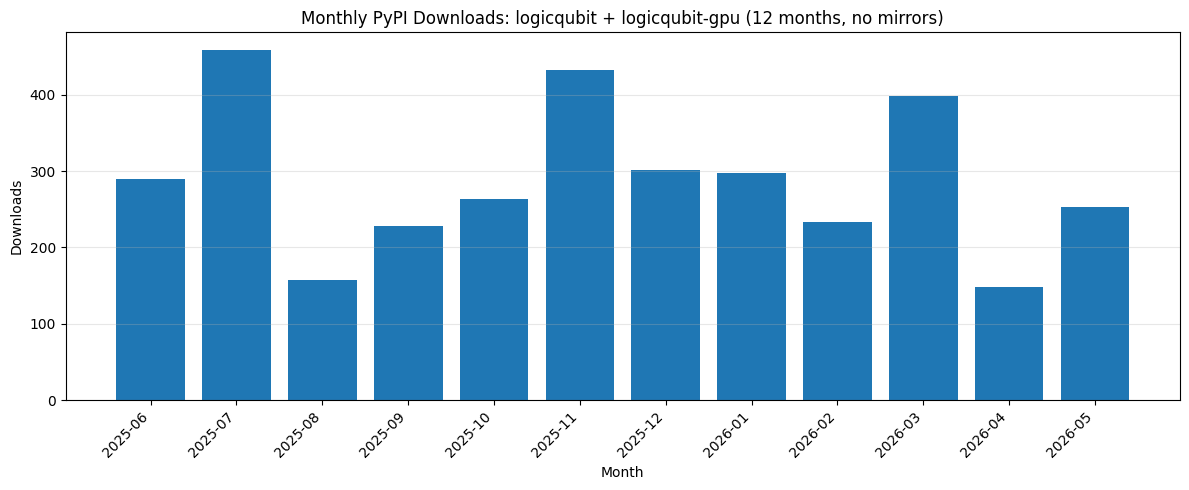

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

NUMBER_OF_MONTHS = 12

PACKAGES = [
    "logicqubit",
    "logicqubit-gpu",
]

monthly_query = """
SELECT
    toStartOfMonth(date) AS month,
    count() AS downloads
FROM pypi.pypi
WHERE
    project IN {packages:Array(String)}

    -- Last complete months, excluding the current incomplete month
    AND date >= addMonths(toStartOfMonth(today()), -{months:UInt8})
    AND date < toStartOfMonth(today())

    -- Exclude known mirrors and empty installer values
    AND lower(ifNull(installer, '')) NOT IN (
        '',
        'bandersnatch',
        'z3c.pypimirror',
        'artifactory',
        'devpi'
    )
GROUP BY month
ORDER BY month
"""

monthly_df = client.query_df(
    monthly_query,
    parameters={
        "packages": [package.lower() for package in PACKAGES],
        "months": NUMBER_OF_MONTHS
    }
)

monthly_df["month"] = pd.to_datetime(monthly_df["month"])
monthly_df["downloads"] = monthly_df["downloads"].astype(int)

def format_number(value):
    return f"{int(value):,}".replace(",", ".")

monthly_df["month_label"] = monthly_df["month"].dt.strftime("%Y-%m")

total_downloads = int(monthly_df["downloads"].sum())

display(monthly_df)

print(
    f"Combined total downloads for {', '.join(PACKAGES)} in the last {NUMBER_OF_MONTHS} complete months:",
    f"{total_downloads:,}".replace(",", ".")
)

plt.figure(figsize=(12, 5))

plt.bar(
    monthly_df["month_label"],
    monthly_df["downloads"]
)

plt.title(f"Monthly PyPI Downloads: logicqubit + logicqubit-gpu ({NUMBER_OF_MONTHS} months, no mirrors)")
plt.xlabel("Month")
plt.ylabel("Downloads")
plt.grid(axis="y", alpha=0.3)

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: format_number(x))
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()